# Regression Analysis
**Input files needed in working directory:**
- `regression_variables_internship.csv`
- `respondent_subcategory_counts.csv` (produced by the pipeline notebook)

**Output files produced:**
- `significant_predictors_all_races.csv`

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

## Load data

In [2]:
reg = pd.read_csv('regression_variables_internship.csv')
media_count = pd.read_csv('respondent_subcategory_counts.csv')

# keep only white respondents because attitude data is only available for this group
white = reg[reg['Race_simplified'] == 'White'].copy()
# how many white respondents
len(white)

544

In [3]:
# column names of the subcategory predictors
subcat_cols = [c for c in media_count.columns if c != 'prolific_id']
subcat_cols

['Podcast | Radio and Podcasts',
 'Print/Online | Local News',
 'Print/Online | National News Channel',
 'Print/Online | Non-News Related',
 'Print/Online | Print & Digital News Outlet',
 'Social Media | Local News',
 'Social Media | National News Channel',
 'Social Media | News Creator',
 'Social Media | Non-News Related',
 'Social Media | Print & Digital News Outlet',
 'TV/Radio | Local News',
 'TV/Radio | National News Channel',
 'TV/Radio | News + Entertainment',
 'TV/Radio | Radio and Podcasts',
 'YouTube | National News Channel',
 'YouTube | News Creator',
 'YouTube | Non-News Related',
 'YouTube | Print & Digital News Outlet']

In [4]:
# merge regression variables with media counts
# left join keeps all white respondents even those without media data
merged = white.merge(media_count, left_on='PROLIFIC_PID', right_on='prolific_id', how='left')
merged[subcat_cols] = merged[subcat_cols].fillna(0).astype(int) # fill missing media counts with 0
# how many respondents have media data
merged['prolific_id'].notna().sum()

np.int64(499)

## Preprocessing

In [5]:
# dummy code categorical variables
# drop_first removes the reference category to avoid perfect multicollinearity
CAT_COLS = ['Gender', 'Occupation', 'Political_leaning']
merged_dum = pd.get_dummies(merged, columns=CAT_COLS, drop_first=True)
dum_cols = [c for c in merged_dum.columns if any(c.startswith(x + '_') for x in CAT_COLS)]
merged_dum[dum_cols] = merged_dum[dum_cols].astype(int) # convert booleans to integers
# which dummy columns were created
dum_cols

['Gender_Male',
 'Occupation_Not full-time',
 'Political_leaning_Independent',
 'Political_leaning_Republican']

In [6]:
# define all race-specific predictor columns without f-strings
# social circle percentage for each race
soccircle_cols = ['White_soccircle_perc', 'Black_soccircle_perc', 'Asian_soccircle_perc', 'Hispanic_soccircle_perc']
# perceived tone of news about each race
tone_cols = ['White_tone_num', 'Black_tone_num', 'Asian_tone_num', 'Hispanic_tone_num']
# how often respondent reads about each race
howoften_cols = ['White_howoftenread_num', 'Black_howoftenread_num', 'Asian_howoftenread_num', 'Hispanic_howoftenread_num']

RACE_NUM = soccircle_cols + tone_cols + howoften_cols

# base numerical predictors
NUM_BASE = ['Age_bin_num', 'Education_num', 'Income_num', 'News_consumption_freq_score', 'SocMedia_consumption_freq_score']

# all columns to standardise
SCALE_COLS = NUM_BASE + subcat_cols + RACE_NUM
merged_dum[SCALE_COLS] = StandardScaler().fit_transform(merged_dum[SCALE_COLS]) # z-score standardisation
# how many columns standardised
len(SCALE_COLS)

35

In [7]:
# define outcome variable names without f-strings
outcomes = ['White_attitude_reduced', 'Black_attitude_reduced', 'Asian_attitude_reduced', 'Hispanic_attitude_reduced']
# check for missing values in all predictors and outcomes
all_pred = NUM_BASE + dum_cols + subcat_cols + RACE_NUM
missing = merged_dum[all_pred + outcomes].isnull().sum()
missing[missing > 0] # show only columns with missing values

Series([], dtype: int64)

In [8]:
# check for high correlations between predictors
# if two predictors correlate above 0.7 one should be dropped
check_cols = NUM_BASE + dum_cols + subcat_cols
corr = merged_dum[check_cols].corr()
# find all pairs with absolute correlation above 0.7
high = []
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        if abs(corr.iloc[i, j]) >= 0.7:
            high.append((corr.columns[i], corr.columns[j], round(corr.iloc[i, j], 3)))
# how many high-correlation pairs found
print(len(high))

0


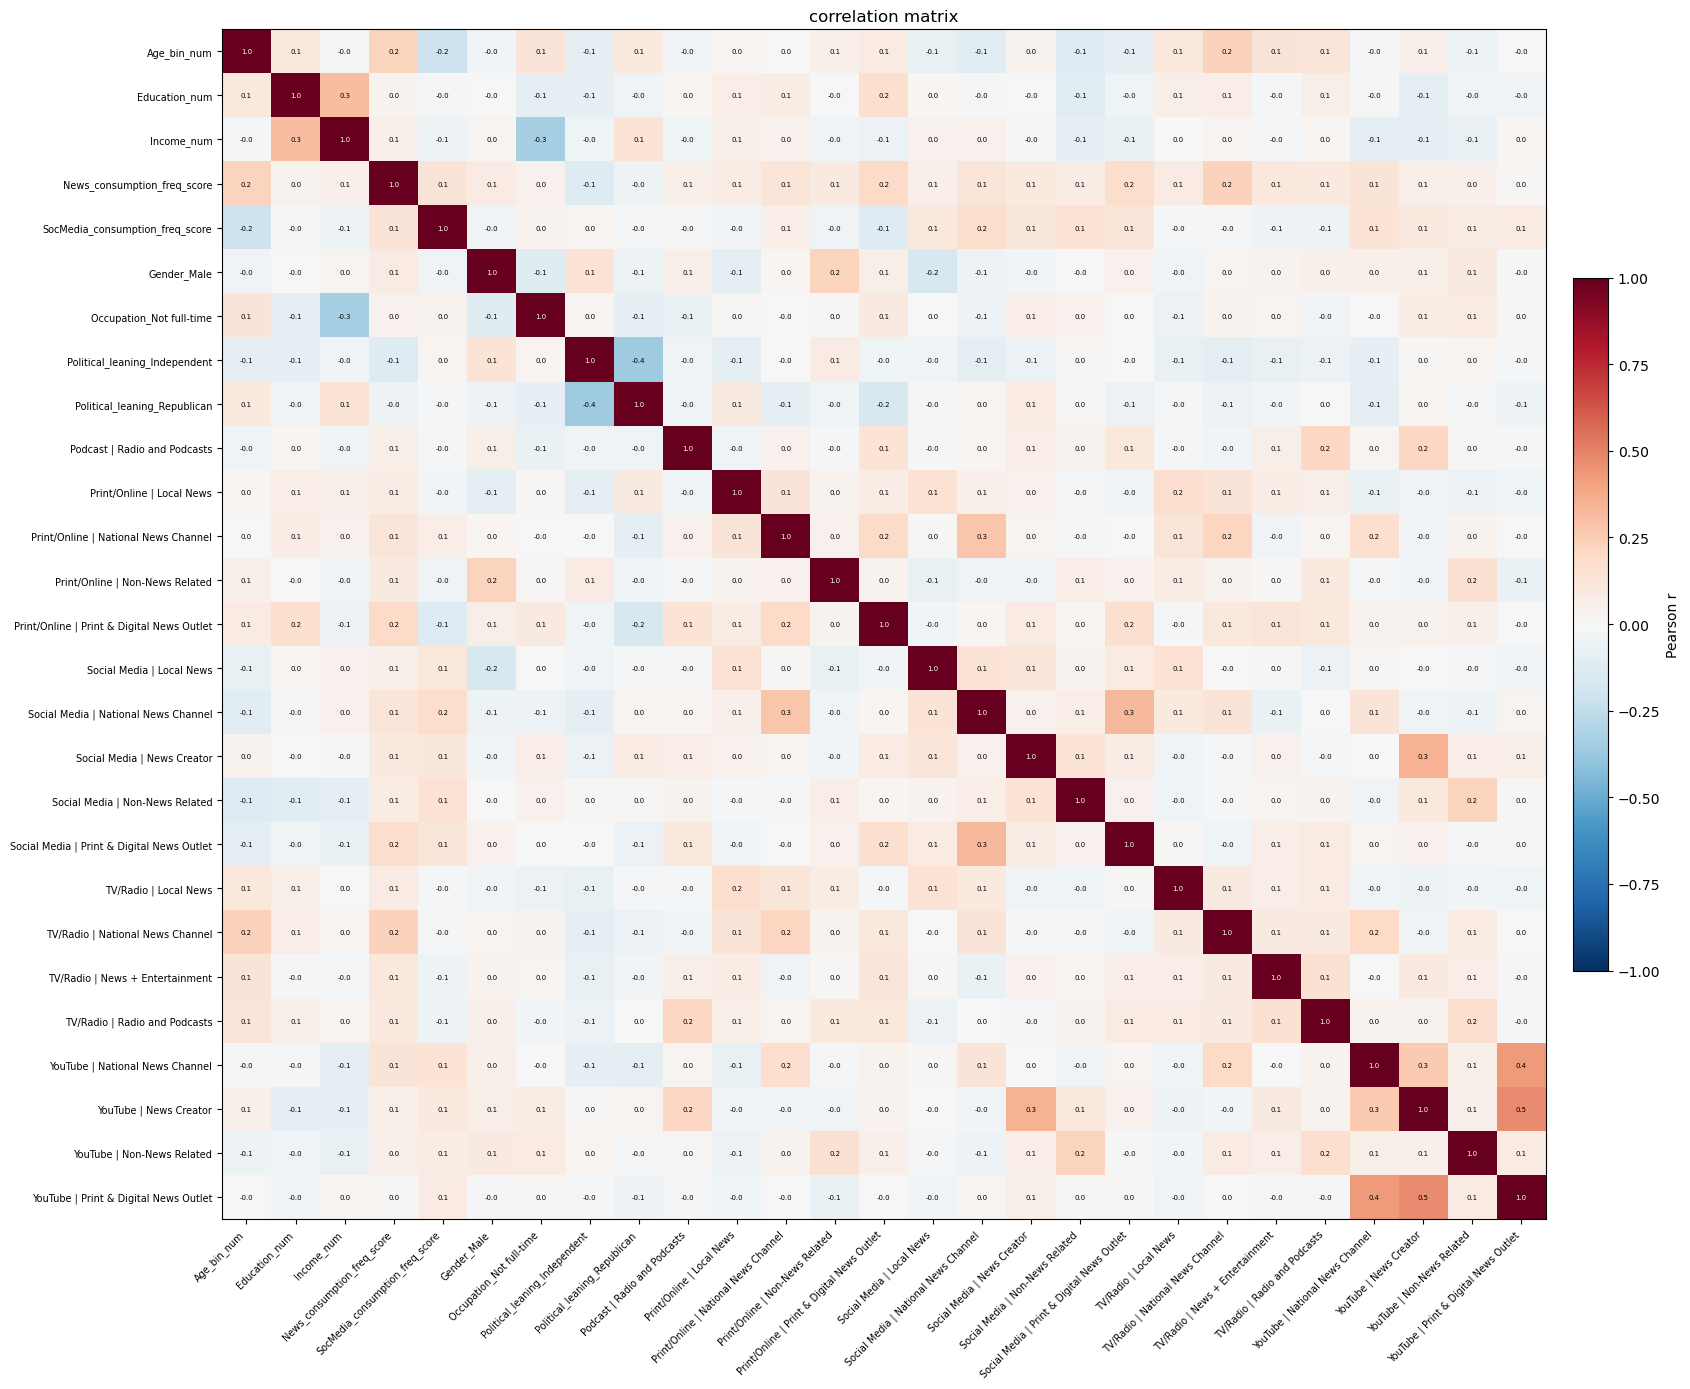

In [10]:
# correlation matrix plot
fig, ax = plt.subplots(figsize=(17, 14))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02, label='Pearson r')
ax.set_xticks(range(len(check_cols)))
ax.set_yticks(range(len(check_cols)))
ax.set_xticklabels(check_cols, rotation=45, ha='right', fontsize=7)
ax.set_yticklabels(check_cols, fontsize=7)
for i in range(len(check_cols)):
    for j in range(len(check_cols)):
        v = corr.iloc[i, j]
        ax.text(j, i, str(round(v, 1)), ha='center', va='center', fontsize=5,
                color='white' if abs(v) > 0.5 else 'black')
ax.set_title('correlation matrix')
plt.tight_layout()
plt.savefig('fig4_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Nested OLS regressions

We run three models for each race adding more predictors each time.
Model 1 uses only sociodemographic variables.
Model 2 adds news subcategory counts.
Model 3 adds race-specific variables like social circle and perceived news tone.
This lets us see how much each group of predictors adds to explaining racial attitudes.

In [11]:
# sociodemographic predictors used in all three models
SOCDEM = [
    'Age_bin_num',
    'Education_num',
    'Income_num',
    'Gender_Male',
    'Occupation_Not full-time',
    'Political_leaning_Independent',
    'Political_leaning_Republican',
]

# race-specific predictors for each race without f-strings
RACE_SP = {
    'White':    ['White_soccircle_perc',    'White_tone_num',    'White_howoftenread_num',    'News_consumption_freq_score', 'SocMedia_consumption_freq_score'],
    'Black':    ['Black_soccircle_perc',    'Black_tone_num',    'Black_howoftenread_num',    'News_consumption_freq_score', 'SocMedia_consumption_freq_score'],
    'Asian':    ['Asian_soccircle_perc',    'Asian_tone_num',    'Asian_howoftenread_num',    'News_consumption_freq_score', 'SocMedia_consumption_freq_score'],
    'Hispanic': ['Hispanic_soccircle_perc', 'Hispanic_tone_num', 'Hispanic_howoftenread_num', 'News_consumption_freq_score', 'SocMedia_consumption_freq_score'],
}

# outcome variable names for each race without f-strings
OUTCOMES = {
    'White':    'White_attitude_reduced',
    'Black':    'Black_attitude_reduced',
    'Asian':    'Asian_attitude_reduced',
    'Hispanic': 'Hispanic_attitude_reduced',
}

RACES = ['White', 'Black', 'Asian', 'Hispanic']

def fit(y, preds, df):
    # fit a single OLS model and return the result
    return sm.OLS(y, sm.add_constant(df[preds].astype(float)), missing='drop').fit()

results = {}
for race in RACES:
    y = merged_dum[OUTCOMES[race]].astype(float) # outcome variable
    m1 = fit(y, SOCDEM, merged_dum) # model 1 sociodemographics only
    m2 = fit(y, SOCDEM + subcat_cols, merged_dum) # model 2 add media subcategories
    m3 = fit(y, SOCDEM + subcat_cols + RACE_SP[race], merged_dum) # model 3 add race-specific variables
    results[race] = {
        'm1': m1,
        'm2': m2,
        'm3': m3,
        'dr2_m2': round(m2.rsquared - m1.rsquared, 4), # r2 gain from adding media
        'dr2_m3': round(m3.rsquared - m2.rsquared, 4), # r2 gain from adding race-specific
    }

In [12]:
# print r2 for each race and model as plain numbers
for race in RACES:
    r = results[race]
    print(race)
    print(round(r['m1'].rsquared, 3), round(r['m2'].rsquared, 3), r['dr2_m2'], round(r['m3'].rsquared, 3), r['dr2_m3'])

White
0.027 0.05 0.0222 0.093 0.0431
Black
0.115 0.138 0.0233 0.156 0.0181
Asian
0.076 0.117 0.0407 0.135 0.0177
Hispanic
0.087 0.113 0.0257 0.121 0.0078


## Visualisations

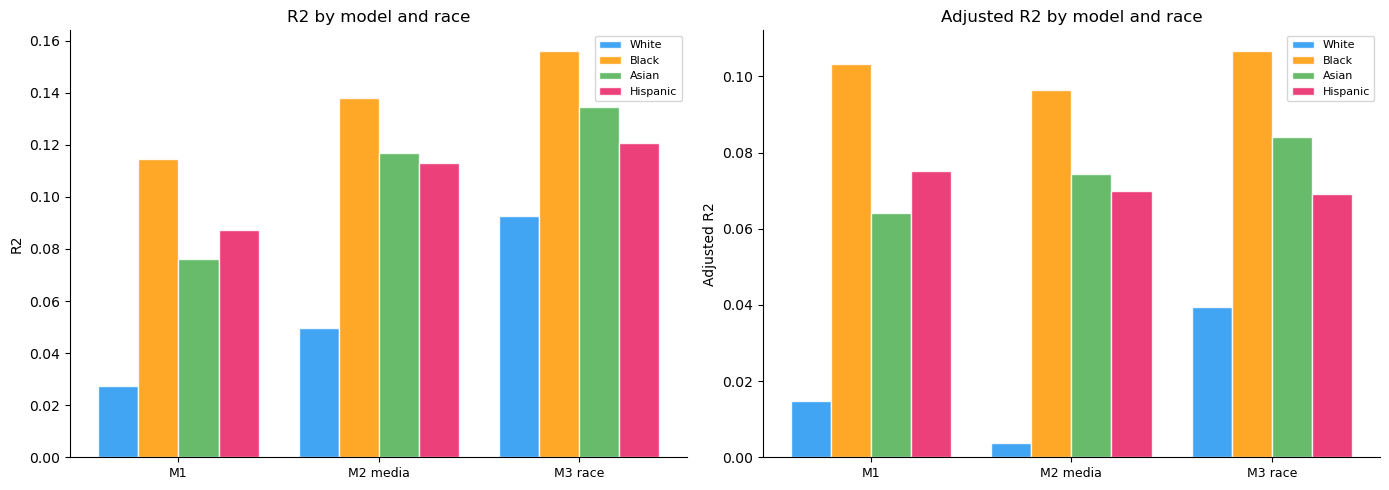

In [13]:
# bar chart comparing r2 across models and races
# each cluster of 4 bars is one model tier, each bar is one race
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2196F3', '#FF9800', '#4CAF50', '#E91E63']
x = np.arange(3)
w = 0.2
labels = ['M1', 'M2 media', 'M3 race']
for ax, attr, title in [(axes[0], 'rsquared', 'R2'), (axes[1], 'rsquared_adj', 'Adjusted R2')]:
    for i, (race, col) in enumerate(zip(RACES, colors)):
        vals = [getattr(results[race][mk], attr) for mk in ['m1', 'm2', 'm3']]
        ax.bar(x + i * w, vals, w, label=race, color=col, alpha=0.85, edgecolor='white')
    ax.set_xticks(x + w * 1.5)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel(title)
    ax.set_title(title + ' by model and race')
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('fig5_r2_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

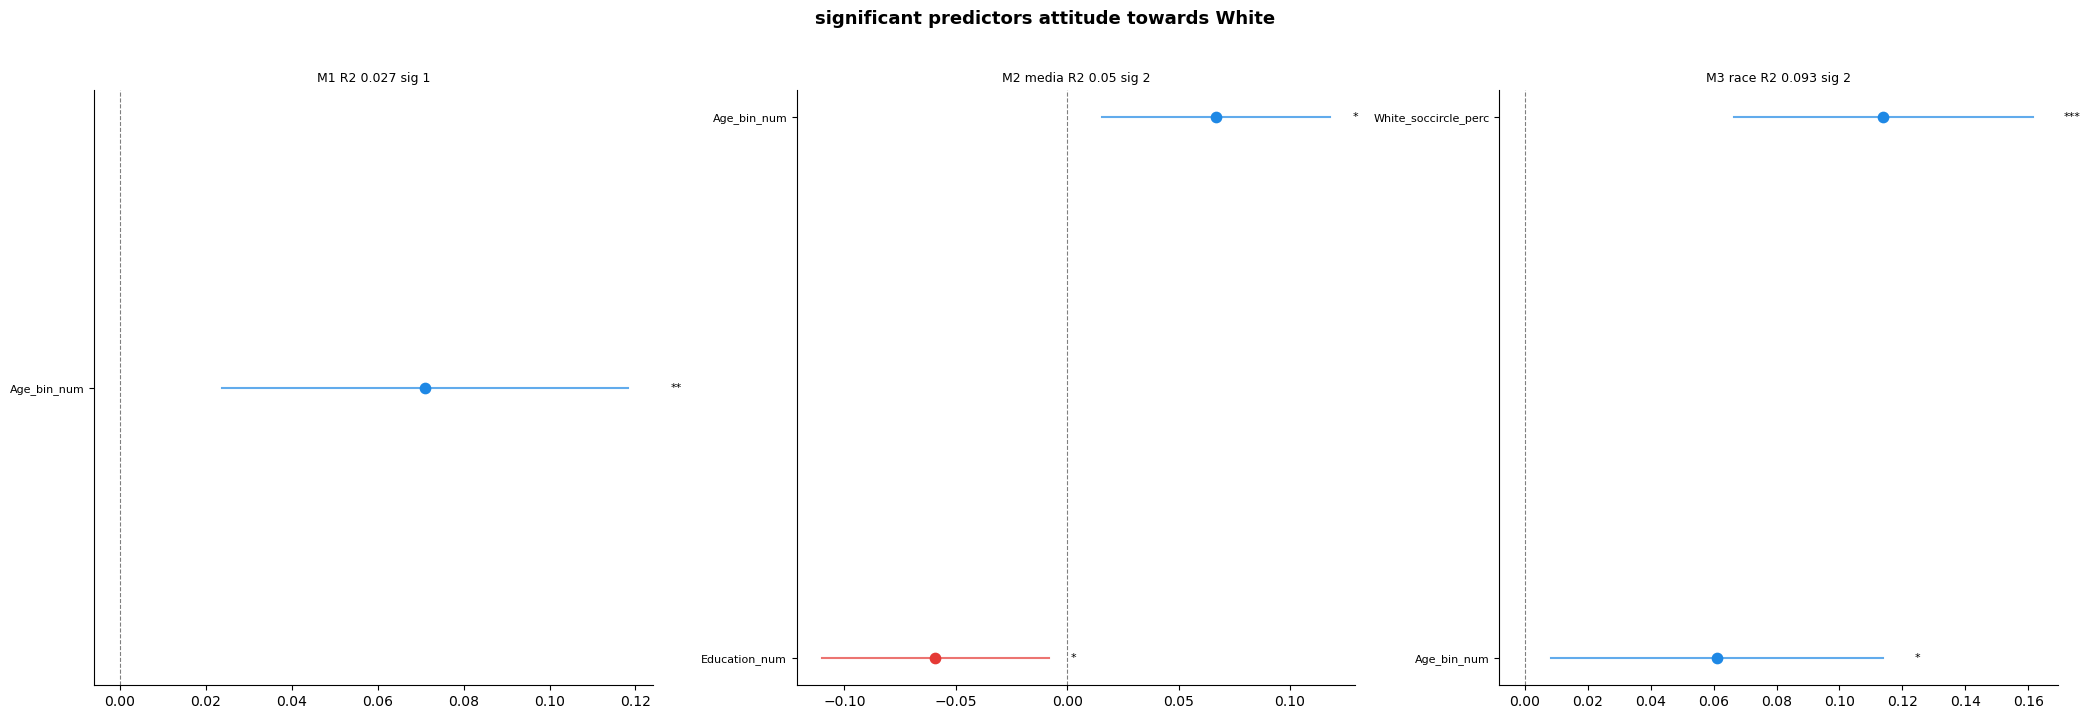

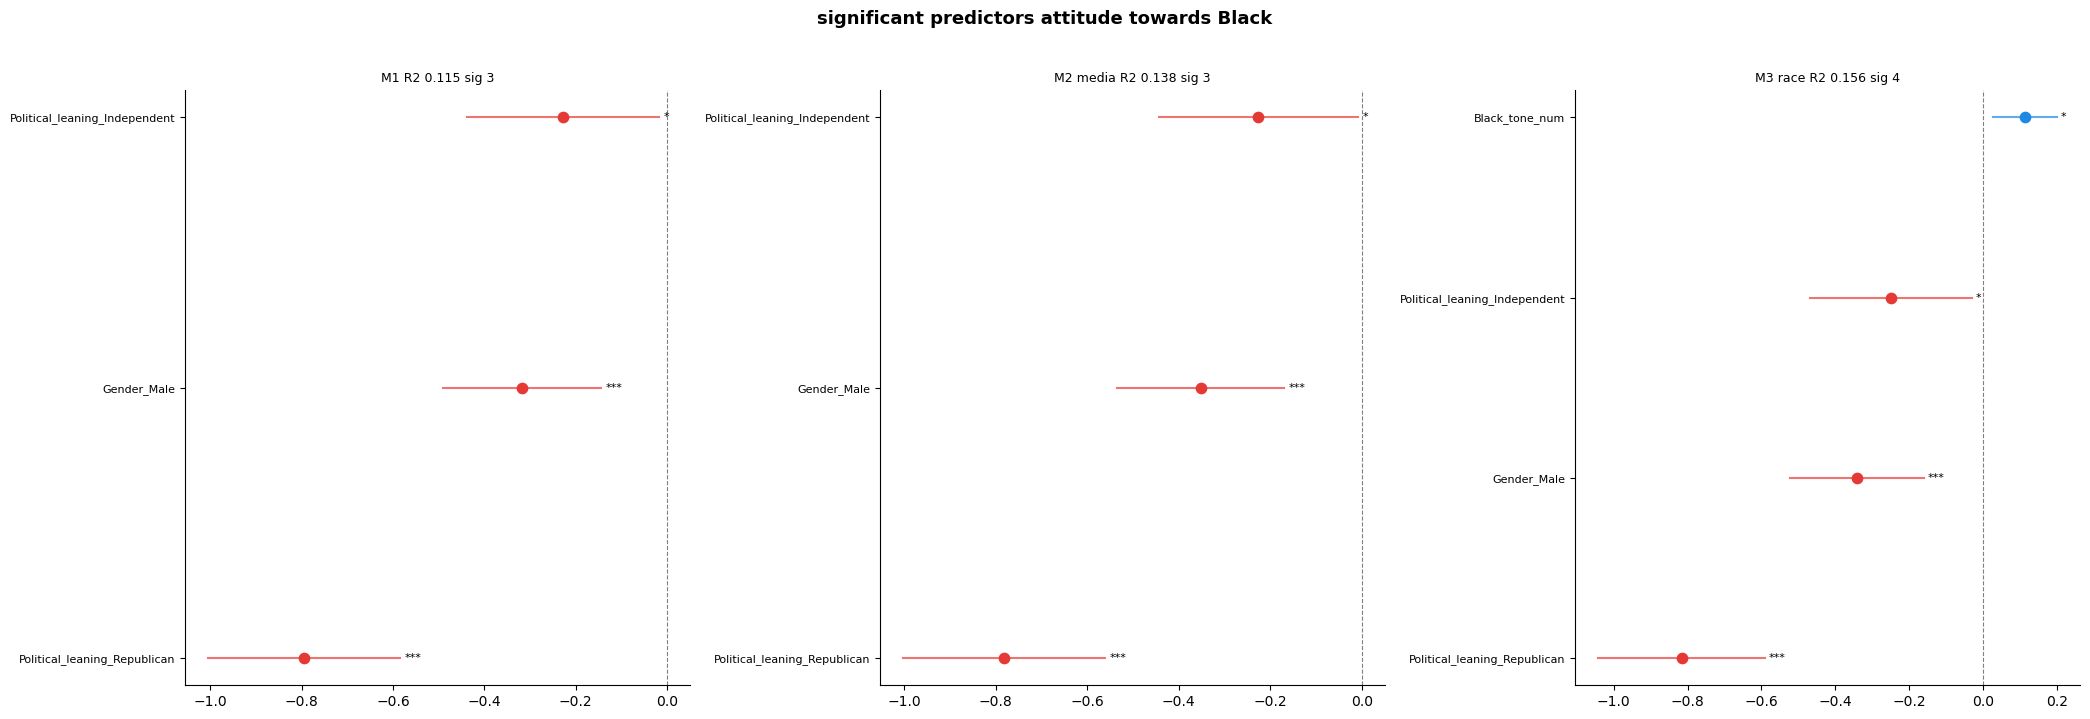

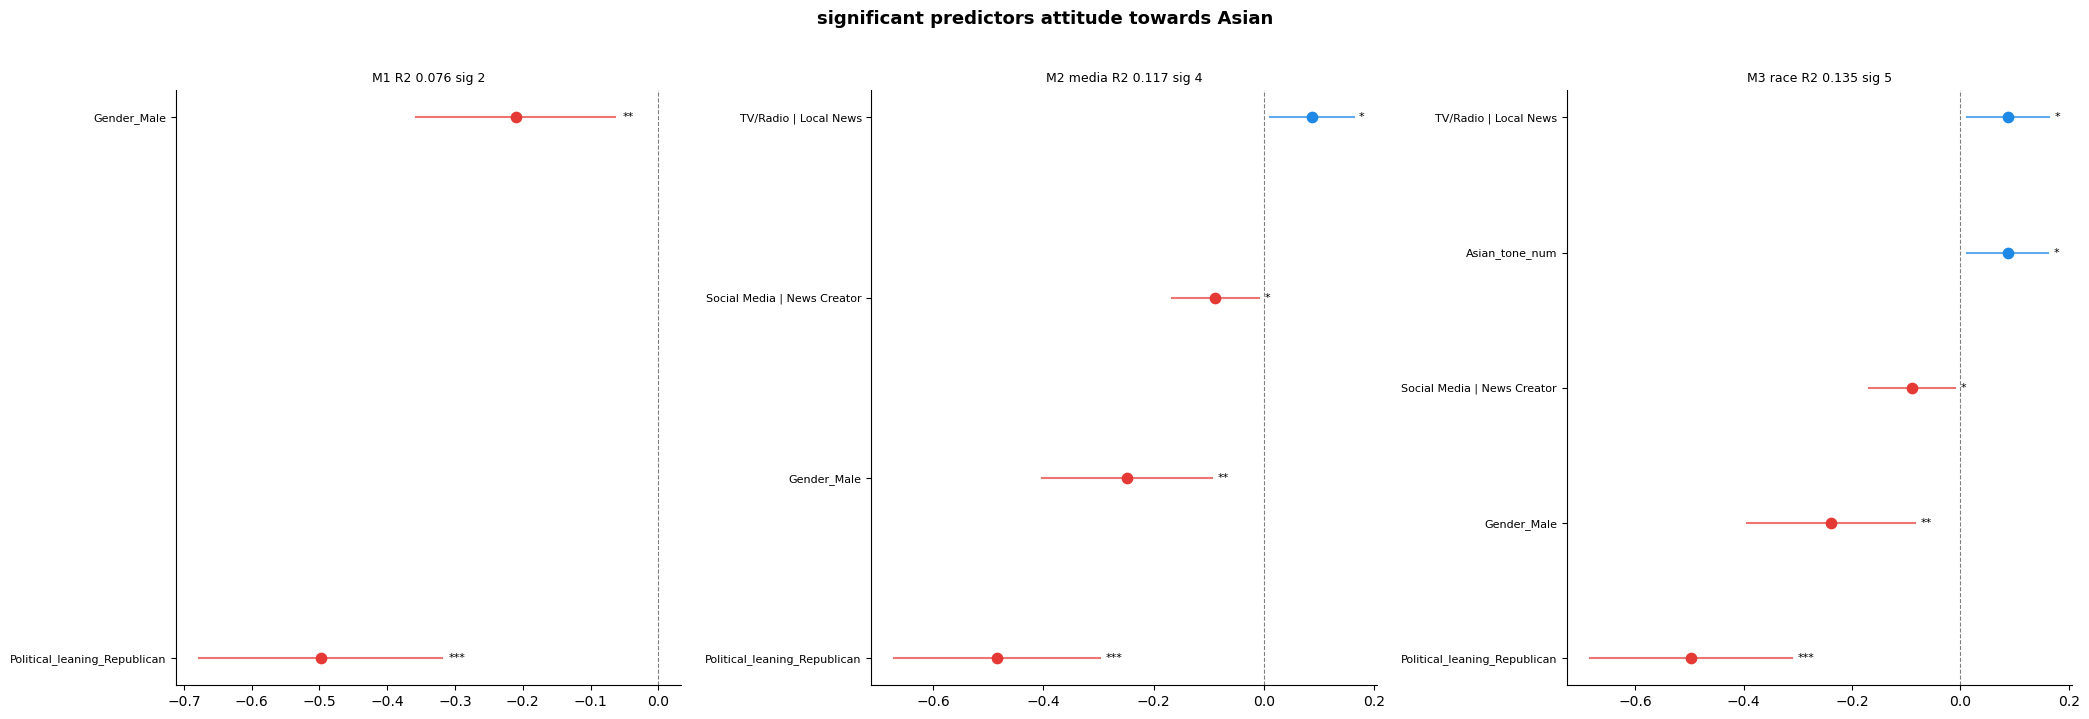

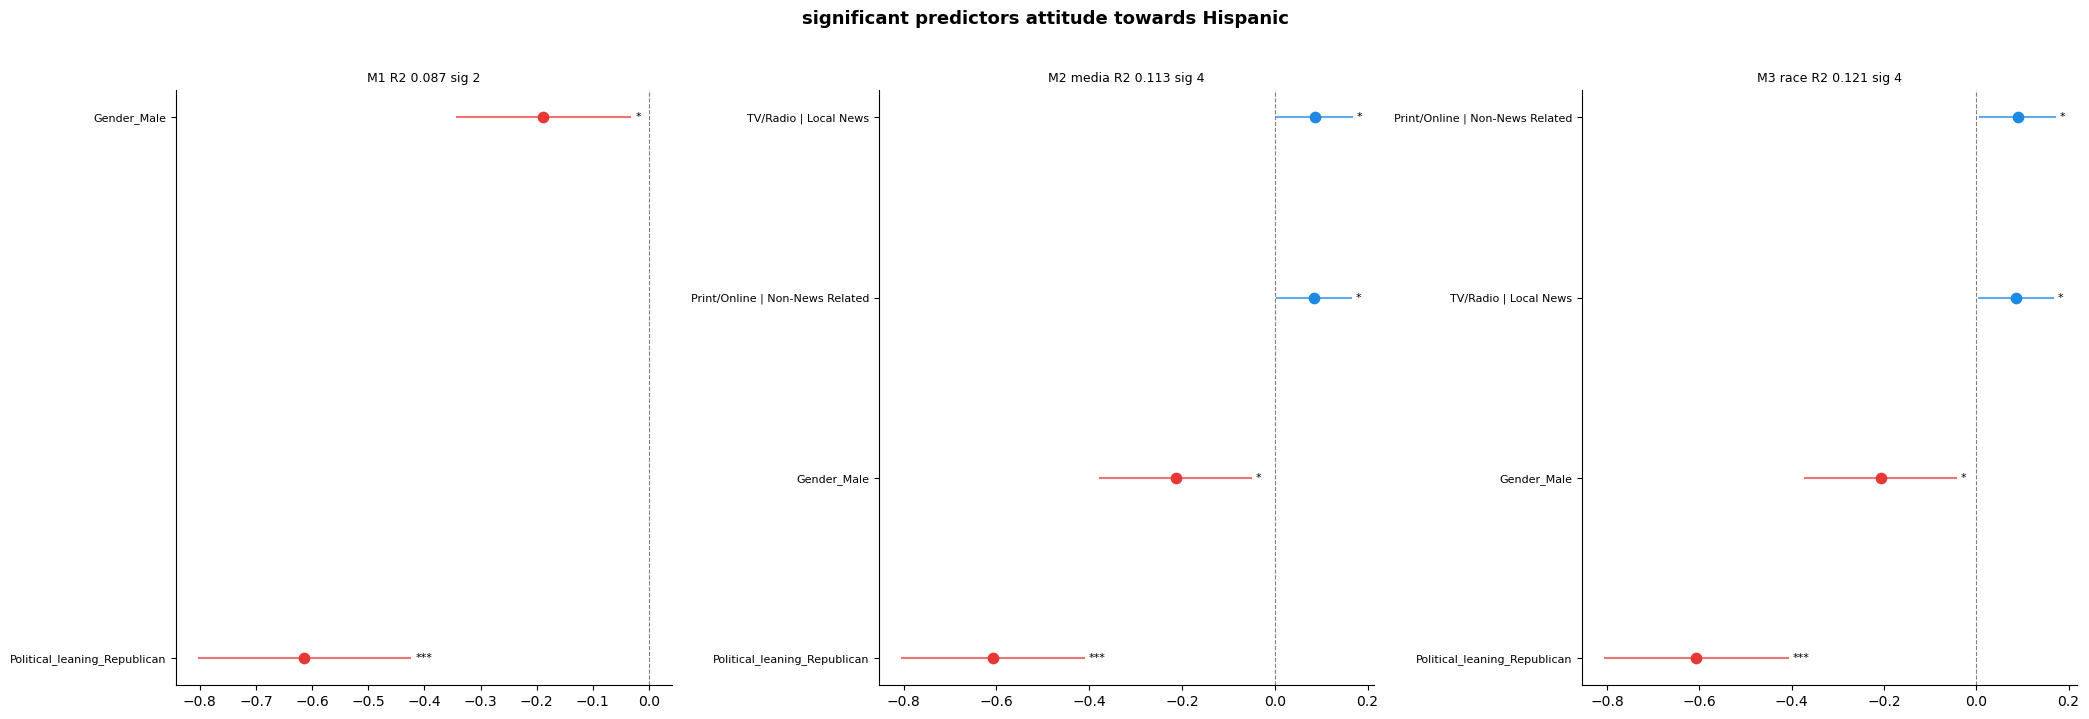

In [14]:
# coefficient plots showing predictors that are significant at p < 0.05
# blue dots are positive associations red dots are negative
# horizontal bars show the 95 percent confidence interval
# stars show significance level

def coef_plot(model, title, ax):
    coef = model.params.drop('const', errors='ignore')
    ci = model.conf_int().drop('const', errors='ignore')
    pval = model.pvalues.drop('const', errors='ignore')
    mask = pval < 0.05 # keep only significant predictors
    coef = coef[mask]
    ci = ci[mask]
    pval = pval[mask]
    if len(coef) == 0:
        ax.text(0.5, 0.5, 'no significant predictors', ha='center', va='center',
                transform=ax.transAxes, color='grey')
        ax.set_title(title, fontsize=9)
        return
    order = coef.sort_values().index # sort from most negative to most positive
    coef = coef[order]
    ci = ci.loc[order]
    pval = pval[order]
    dotcols = ['#E53935' if v < 0 else '#1E88E5' for v in coef] # red negative blue positive
    ax.axvline(0, color='black', lw=0.8, ls='--', alpha=0.5)
    for i, (name, val) in enumerate(coef.items()):
        lo = ci.loc[name, 0]
        hi = ci.loc[name, 1]
        ax.plot([lo, hi], [i, i], color=dotcols[i], lw=1.5, alpha=0.7) # confidence interval line
        ax.scatter(val, i, color=dotcols[i], s=55, zorder=5) # coefficient dot
        p = pval[name]
        stars = '***' if p < 0.001 else '**' if p < 0.01 else '*'
        ax.text(hi + 0.01, i, stars, va='center', fontsize=8)
    ax.set_yticks(range(len(coef)))
    ax.set_yticklabels(coef.index, fontsize=8)
    ax.set_title(title, fontsize=9, pad=6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

for race in RACES:
    r = results[race]
    fig, axes = plt.subplots(1, 3, figsize=(21, 7))
    for ax, (lbl, m) in zip(axes, [('M1', r['m1']), ('M2 media', r['m2']), ('M3 race', r['m3'])]):
        nsig = (m.pvalues.drop('const', errors='ignore') < 0.05).sum()
        coef_plot(m, lbl + ' R2 ' + str(round(m.rsquared, 3)) + ' sig ' + str(nsig), ax)
    fig.suptitle('significant predictors attitude towards ' + race, fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('fig6_coef_' + race.lower() + '.png', dpi=150, bbox_inches='tight')
    plt.show()

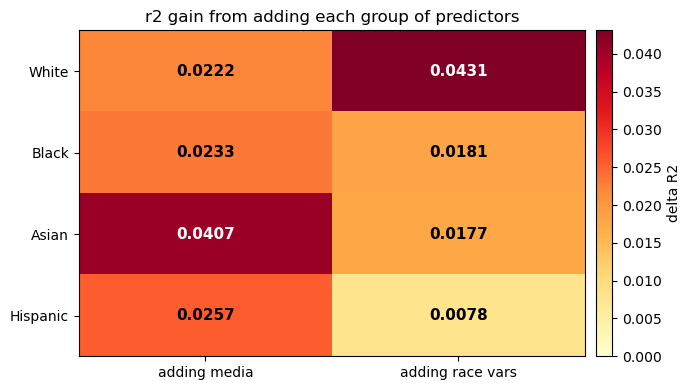

In [15]:
# heatmap showing how much r2 increases when we add each group of predictors
# first column is the gain from adding media subcategories to sociodemographics
# second column is the gain from adding race-specific variables to media
delta_rows = [
    [results['White']['dr2_m2'],    results['White']['dr2_m3']],
    [results['Black']['dr2_m2'],    results['Black']['dr2_m3']],
    [results['Asian']['dr2_m2'],    results['Asian']['dr2_m3']],
    [results['Hispanic']['dr2_m2'], results['Hispanic']['dr2_m3']],
]
row_labels = ['White', 'Black', 'Asian', 'Hispanic']
col_labels = ['adding media', 'adding race vars']

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(delta_rows, cmap='YlOrRd', aspect='auto', vmin=0)
plt.colorbar(im, ax=ax, label='delta R2', fraction=0.04, pad=0.02)
ax.set_xticks(range(2))
ax.set_xticklabels(col_labels, fontsize=10)
ax.set_yticks(range(4))
ax.set_yticklabels(row_labels, fontsize=10)
for i in range(4):
    for j in range(2):
        v = delta_rows[i][j]
        ax.text(j, i, str(round(v, 4)), ha='center', va='center', fontsize=11,
                color='black' if v < 0.04 else 'white', fontweight='bold')
ax.set_title('r2 gain from adding each group of predictors')
plt.tight_layout()
plt.savefig('fig7_delta_r2_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# table of all significant predictors across races and models
rows = []
for race in RACES:
    for mk, ml in [('m1', 'M1'), ('m2', 'M2'), ('m3', 'M3')]:
        m = results[race][mk]
        params = m.params.drop('const', errors='ignore')
        pvals = m.pvalues.drop('const', errors='ignore')
        cis = m.conf_int().drop('const', errors='ignore')
        for pred in params.index:
            p = pvals[pred]
            if p < 0.05:
                rows.append({
                    'Race': race,
                    'Model': ml,
                    'Predictor': pred,
                    'Coef': round(params[pred], 4),
                    'CI_low': round(cis.loc[pred, 0], 4),
                    'CI_high': round(cis.loc[pred, 1], 4),
                    'p': round(p, 4),
                    'Sig': '***' if p < 0.001 else '**' if p < 0.01 else '*',
                })
sig_df = pd.DataFrame(rows)
# how many significant predictor-race-model combinations
print(len(sig_df))

36


In [17]:
# show the full table
sig_df

,Race,Model,Predictor,Coef,CI_low,CI_high,p,Sig
0,White,M1,Age_bin_num,0.0710,0.0239,0.1182,0.0032,**
1,White,M2,Age_bin_num,0.0668,0.0158,0.1179,0.0104,*
2,White,M2,Education_num,-0.0591,-0.1099,-0.0084,0.0224,*
3,White,M3,Age_bin_num,0.0611,0.0085,0.1138,0.0230,*
4,White,M3,White_soccircle_perc,0.1140,0.0666,0.1614,0.0000,***
5,Black,M1,Gender_Male,-0.3175,-0.4903,-0.1448,0.0003,***
6,Black,M1,Political_leaning_Independent,-0.2279,-0.4375,-0.0183,0.0331,*
7,Black,M1,Political_leaning_Republican,-0.7942,-1.0046,-0.5838,0.0000,***
8,Black,M2,Gender_Male,-0.3526,-0.5353,-0.1700,0.0002,***
9,Black,M2,Political_leaning_Independent,-0.2263,-0.4435,-0.0091,0.0412,*


In [18]:
# full statsmodels output for each race and model
for race in RACES:
    for mk, ml in [('m1', 'M1 sociodem'), ('m2', 'M2 media'), ('m3', 'M3 race')]:
        print('=' * 60)
        print(race, ml)
        print('=' * 60)
        print(results[race][mk].summary())

White M1 sociodem
                              OLS Regression Results                              
Dep. Variable:     White_attitude_reduced   R-squared:                       0.027
Model:                                OLS   Adj. R-squared:                  0.015
Method:                     Least Squares   F-statistic:                     2.155
Date:                    Mon, 08 Jun 2026   Prob (F-statistic):             0.0367
Time:                            01:49:54   Log-Likelihood:                -439.24
No. Observations:                     544   AIC:                             894.5
Df Residuals:                         536   BIC:                             928.9
Df Model:                               7                                         
Covariance Type:                nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------

In [ ]:
sig_df.to_csv('significant_predictors_all_races.csv', index=False)